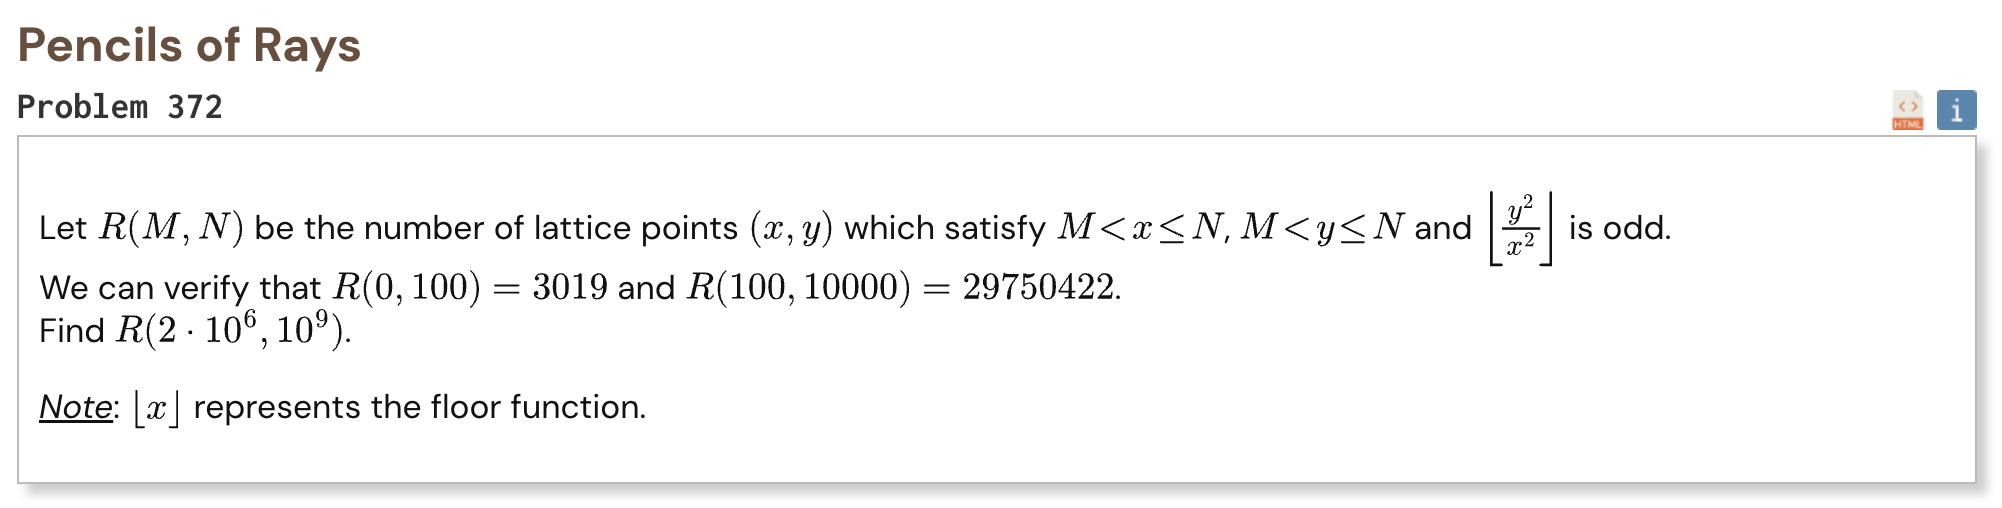

## Initial approach

* count points by odd bands instead of checking every point
* for each odd band, split the x range into capped and uncapped parts
* replace the inner x loop with a fast sum of square-root floor values
* use a recursive Beatty-style function for those sums
* keep everything in integer arithmetic to avoid precision errors
* verify the two sample values before solving the target

In [1]:
import math
from functools import lru_cache

def normalize(p, s, d, q):
    if q < 0:
        p = -p
        s = -s
        q = -q

    g = math.gcd(math.gcd(abs(p), abs(s)), abs(q))

    if g > 1:
        p //= g
        s //= g
        q //= g

    return p, s, d, q

def expression_leq(p, s, d, q, n, y):
    t = q * y - n * p

    if t <= 0:
        return True

    return t * t < n * n * s * s * d

def floor_quadratic_irrational(p, s, d, q, n):
    y = (n * p + math.isqrt(n * n * s * s * d)) // q

    while expression_leq(p, s, d, q, n, y + 1):
        y += 1

    while not expression_leq(p, s, d, q, n, y):
        y -= 1

    return y

@lru_cache(None)
def beatty_sum(n, p, s, d, q):
    if n <= 0:
        return 0

    a = floor_quadratic_irrational(p, s, d, q, 1)

    if a >= 1:
        return a * n * (n + 1) // 2 + beatty_sum(n, p - a * q, s, d, q)

    m = floor_quadratic_irrational(p, s, d, q, n)

    if m == 0:
        return 0

    denominator = s * s * d - p * p

    next_p = -q * p
    next_s = q * s
    next_q = denominator

    next_p, next_s, d, next_q = normalize(next_p, next_s, d, next_q)

    return m * n - beatty_sum(m, next_p, next_s, d, next_q)

def floor_sum_sqrt(d, n):
    root = math.isqrt(d)

    if root * root == d:
        return root * n * (n + 1) // 2

    return beatty_sum(n, 0, 1, d, 1)

def sum_ceil_sqrt(d, left, right):
    if right < left:
        return 0

    root = math.isqrt(d)
    count = right - left + 1

    if root * root == d:
        return root * (left + right) * count // 2

    return floor_sum_sqrt(d, right) - floor_sum_sqrt(d, left - 1) + count

def max_x_for_low(d, n):
    return math.isqrt((n * n) // d)

def max_x_for_high(d, n):
    return math.isqrt(((n + 1) * (n + 1)) // d)

def R(M, N):
    total = 0
    first_x = M + 1
    max_k = (N * N) // (first_x * first_x)

    for k in range(1, max_k + 1, 2):
        last_x_low = max_x_for_low(k, N)

        if last_x_low < first_x:
            continue

        last_x_high = max_x_for_high(k + 1, N)
        full_end = min(last_x_low, last_x_high, N)

        if full_end >= first_x:
            total += sum_ceil_sqrt(k + 1, first_x, full_end)
            total -= sum_ceil_sqrt(k, first_x, full_end)

        capped_start = max(first_x, full_end + 1)

        if capped_start <= last_x_low:
            count = last_x_low - capped_start + 1
            total += count * (N + 1)
            total -= sum_ceil_sqrt(k, capped_start, last_x_low)

    return total

assert R(0, 100) == 3019
assert R(100, 10000) == 29750422

In [2]:
%%time
result = R(2_000_000, 1_000_000_000)
print("Result:", result)

Result: 301450082318807027
CPU times: user 23.6 s, sys: 588 ms, total: 24.2 s
Wall time: 24.3 s
